In [2]:
from sklearn.datasets import load_iris
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.ensemble import RandomForestClassifier

import pandas as pd
import numpy as np

import plotly.express as px
import plotly.graph_objects as go
from plotly.offline import plot,iplot,init_notebook_mode,download_plotlyjs

In [3]:
iris = load_iris()
print(iris.keys())

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


In [10]:
print(type(iris))

<class 'sklearn.utils._bunch.Bunch'>


In [5]:
print("Features Used: ")
print(iris["feature_names"])

Features Used: 
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [6]:
print("Targets Used: ")
print(iris["target_names"])

Targets Used: 
['setosa' 'versicolor' 'virginica']


In [9]:
print("Description of the Dataset (similar to pd.DataFrame.describe()): ")
print(iris["DESCR"])

Description of the Dataset (similar to pd.DataFrame.describe()): 
.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute 

In [13]:
df = pd.DataFrame(
    iris["data"],
    columns = iris["feature_names"])

In [15]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [18]:
df_species = pd.DataFrame(iris["target"],columns=["species"])
df_species.head()

,species
0,0
1,0
2,0
3,0
4,0


In [21]:
df_iris = pd.concat([df,df_species],axis =1)
df_iris.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [22]:
df_iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [25]:
split = StratifiedShuffleSplit(n_splits=1, test_size=0.10, random_state=17)
for train_idx, test_idx in split.split(df_iris, df_iris["species"]):
    strat_train = df_iris.iloc[train_idx]
    strat_test = df_iris.iloc[test_idx]

In [26]:
print(f"Shape of the Training Set: {strat_train.shape}")
strat_train.head()

Shape of the Training Set: (135, 5)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
82,5.8,2.7,3.9,1.2,1
68,6.2,2.2,4.5,1.5,1
140,6.7,3.1,5.6,2.4,2
123,6.3,2.7,4.9,1.8,2
126,6.2,2.8,4.8,1.8,2


In [27]:
print(f"Shape of the Testing Set: {strat_test.shape}")
strat_test.head()

Shape of the Testing Set: (15, 5)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
103,6.3,2.9,5.6,1.8,2
15,5.7,4.4,1.5,0.4,0
6,4.6,3.4,1.4,0.3,0
45,4.8,3.0,1.4,0.3,0
102,7.1,3.0,5.9,2.1,2


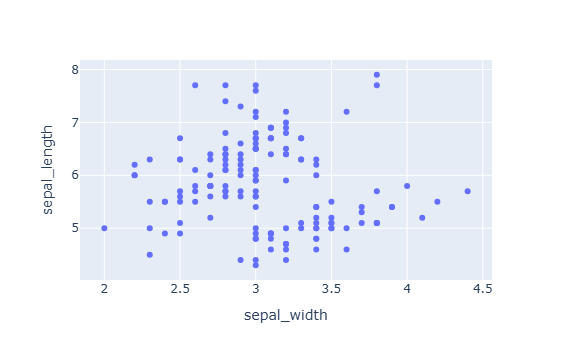

In [33]:
df = px.data.iris()
fig = px.scatter(df, x="sepal_width", y="sepal_length")
fig.show()

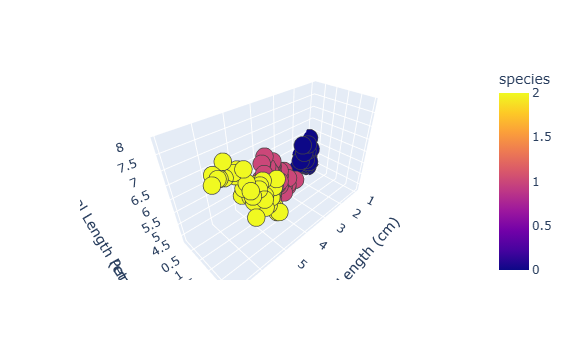

In [35]:
targets = iris["target_names"]

fig = px.scatter_3d(df_iris, x="petal length (cm)", y="petal width (cm)", z="sepal length (cm)", color="species",
                   hover_name=targets[df_iris["species"]],
                   labels={
                       "petal length (cm)": "Petal Length (cm)",
                       "petal width (cm)": "Petal Width (cm)",
                       "sepal length (cm)": "Sepal Length (cm)"
                   })
fig.update_traces(marker_line_width=4, marker_size=10)

In [37]:
corr_matrix = df_iris.corr()
corr_matrix["species"].sort_values(ascending=False)

species              1.000000
petal width (cm)     0.956547
petal length (cm)    0.949035
sepal length (cm)    0.782561
sepal width (cm)    -0.426658
Name: species, dtype: float64

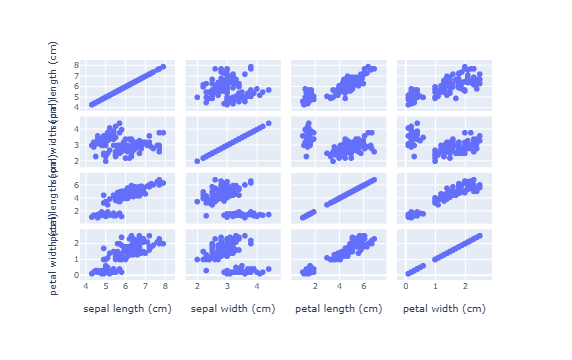

In [40]:
fig = px.scatter_matrix(df_iris.drop("species", axis=1))
fig.update_layout(font=dict(size=8))

In [41]:
# Seperating the Training Set
X_train = strat_train.drop("species", axis=1)
y_train = strat_train["species"]

# Seperating the Test Set
X_test = strat_test.drop("species", axis=1)
y_test = strat_test["species"]

In [42]:
tree_classifier = RandomForestClassifier()
tree_classifier.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [48]:
predictions = tree_classifier.predict(X_test)
n_correct = sum(predictions == y_test)
print("Score of Predictions: ", n_correct / len(predictions))

Score of Predictions:  1.0
